In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Database.DB_reader import Database
import datetime as dt
from Utilities.fund_analysis.fund_analysis.utils import spreads_creation
from collections import defaultdict
import scipy.stats as stats

In [2]:
db = Database()

In [9]:
# Fetch all spot data

markets = ['de', 'fr']  # List of market codes; adjust as needed
end_date = dt.datetime.today().replace(hour=0, minute=0, second=0, microsecond=0) + pd.DateOffset(days=2, hours=-1)
start_date = end_date - pd.DateOffset(months=3, hours=-1)

spot_list = []

for market in markets:    
    # If the actual table names are different, adjust the table name accordingly.
    query = f"""
    SELECT *
    FROM "spot"."{market}"
    WHERE datetime >= '{start_date}'
      AND datetime <= '{end_date}'
    """
    spot_list.append(pd.read_sql(query, db.connection_string)[['datetime', 'price']].set_index('datetime').sort_index())

spot = pd.concat(spot_list, keys=markets, axis=1)

In [10]:
# Select market for base peak analysis
market = 'de'
# Create base and peak data
spot_leg1 = spot['de'].resample('D').mean()
spot_leg2 = spot['fr'].resample('D').mean()
# Compute correlation between base and peak
corr_ = spot_leg1['price'].diff().corr(spot_leg2['price'].diff())
corr_matrix = np.array([[1, corr_], [corr_, 1]])

print(corr_matrix)

[[1.         0.71643716]
 [0.71643716 1.        ]]


In [11]:
markets = ['de', 'fr']
delivery = ['base', 'peak']
periods = ['W_1', 'W_2', 'W_3']
fcst_date = '2025-04-04'

# Build condition strings for each filter list
market_condition = ", ".join(f"'{m}'" for m in markets)
delivery_condition = ", ".join(f"'{d}'" for d in delivery)
periods_condition = ", ".join(f"'{p}'" for p in periods)

query_spot = f"""
    SELECT *
    FROM "MODEL_forecast_prices"."xgboost_mean"
    WHERE fcst_date = '2025-04-04'
      AND rel_product IN ({periods_condition})
      AND del_type IN ({delivery_condition})
      AND market IN ({market_condition})
      AND scenario_type IN ('base_col', 'perc_col')
"""

fcst_data = pd.read_sql(query_spot, con=db.connection_string)

# Create a nested defaultdict structure
fcst_dict = defaultdict(lambda: defaultdict(lambda: defaultdict(dict)))

for market in markets:
    for period in periods:
        for del_type in delivery:
            # Use parentheses for each condition
            temp = fcst_data.loc[
                (fcst_data['rel_product'] == period) &
                (fcst_data['market'] == market) &
                (fcst_data['del_type'] == del_type)
            ].copy()
            
            # Check that temp is not empty to avoid errors
            if not temp.empty:
                # If you expect only one row, select the first row and convert to list
                fcst_dict[market][period][del_type]['perc'] = temp['value'].loc[temp['value_type'].isin(['10th_perc', '25th_perc',
                                                                                                         '75th_perc', '90th_perc'])].to_list()
                # For the 'base' value, extract the first row's value
                fcst_dict[market][period][del_type]['mean'] = temp['value'].loc[temp['value_type'].isin(['base'])].to_list()
            else:
                # Handle the case where no matching data exists (optional)
                fcst_dict[market][period][del_type]['perc'] = None
                fcst_dict[market][period][del_type]['mean'] = None


In [14]:
# Simulate selected periods
period = 'W_1'
market1 = 'de'
market2 = 'fr'

leg1_perc = fcst_dict[market1][period]['base']['perc']
leg1_mean = fcst_dict[market1][period]['base']['mean']
leg2_perc = fcst_dict[market2][period]['peak']['perc']
leg2_mean = fcst_dict[market2][period]['peak']['mean']

# Percentiles list
perc = [0.1, 0.25, 0.75, 0.9]
# Set samples
n_samples = 1000

# Model percnentiles
# Estimate sigma using p10 and p90 for a normal distribution:
sigma_base = (leg1_perc[-1] - leg1_perc[0]) / (2 * 1.28)  # approx. using the normal quantiles
sigma_peak = (leg2_perc[-1] - leg2_perc[0]) / (2 * 1.28)  # approx. using the normal quantiles

# Generate standard normal samples with the specified correlation
norm_samples = np.random.multivariate_normal(mean=[0, 0], cov=corr_matrix, size=n_samples)

# Transform the samples to uniforms [0, 1] via the standard normal CDF
u = stats.norm.cdf(norm_samples)

# Transform the uniform samples to the desired marginals using the inverse CDF (ppf)
base_simulated = stats.norm.ppf(u[:, 0], loc=leg1_mean, scale=sigma_base)
peak_simulated = stats.norm.ppf(u[:, 1], loc=leg2_mean, scale=sigma_peak)

# ---------------------------
# Step 4: Compute the Spread and Analyze
# ---------------------------
spreads = base_simulated - peak_simulated
spreads *= 55

print("Mean Spread:", np.mean(spreads))
print("Spread Percentiles (10th, 25th, 75th, 90th):", np.percentile(spreads, [10, 25, 75, 90]))

score = 7 # your specific spread value
percentile = stats.percentileofscore(spreads, score, kind='rank')
print(f"The spread value {score} is at the {percentile:.2f}th percentile.")



Mean Spread: 29.68808713241697
Spread Percentiles (10th, 25th, 75th, 90th): [14.58485916 22.27479229 37.15031912 44.88937631]
The spread value 7 is at the 2.70th percentile.


(array([ 11.,  40., 125., 222., 268., 200.,  90.,  37.,   5.,   2.]),
 array([-37.35301544, -31.93213959, -26.51126374, -21.09038789,
        -15.66951204, -10.24863619,  -4.82776034,   0.59311551,
          6.01399136,  11.43486721,  16.85574306]),
 <BarContainer object of 10 artists>)

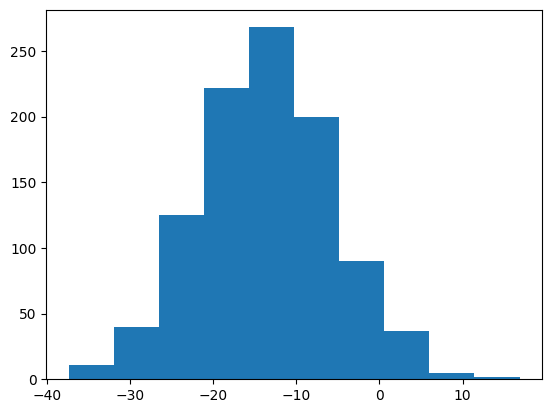

In [14]:
plt.hist(spreads)